In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression as lr 
from sklearn.preprocessing import LabelEncoder as le
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler as ss
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier as knn
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.ensemble import RandomForestClassifier as rfc
from sklearn.naive_bayes import GaussianNB as gnb
from xgboost import XGBClassifier as xgbc 
import joblib
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

# IMPORTING THE DATA

In [2]:
df = pd.read_csv("star_classification.csv")
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


# EDA AND UNDERSTANDING OF THE DATA

In [3]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [5]:
df.sample(20)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
54186,1.237654e+18,134.783302,1.955177,22.48270,21.73445,21.61612,21.62582,20.93466,1907,301,4,81,4.296653e+18,STAR,0.000739,3816,55272,798
86480,1.237679e+18,36.609849,2.759015,23.94940,22.13702,20.62667,19.70931,19.28240,7717,301,5,574,4.802198e+18,GALAXY,0.500906,4265,55505,855
52054,1.237680e+18,354.654854,21.028065,21.28800,21.17403,21.13218,20.72874,20.33130,8108,301,1,208,8.558178e+18,QSO,2.071683,7601,56959,773
27496,1.237671e+18,141.040702,13.397597,21.70143,21.69629,20.77559,19.72566,19.21582,5972,301,5,172,5.976480e+18,GALAXY,0.687009,5308,55976,739
72343,1.237661e+18,144.606071,34.213930,21.28422,21.15266,21.23041,20.83205,21.07166,3647,301,2,50,1.151693e+19,QSO,1.799610,10229,58441,366
75857,1.237661e+18,136.757900,35.129801,20.26877,18.26299,17.30661,16.88722,16.53919,3606,301,6,93,1.364626e+18,GALAXY,0.106037,1212,52703,128
25785,1.237659e+18,250.179467,36.691503,22.28031,22.10238,21.66062,21.60695,21.20483,3225,301,4,263,1.207641e+19,QSO,1.232556,10726,58199,34
33687,1.237679e+18,16.794992,13.386494,23.06152,23.03871,21.58835,20.29076,19.49691,7773,301,6,419,5.251357e+18,GALAXY,0.693716,4664,56192,580
19021,1.237661e+18,177.726179,58.243757,24.01935,24.33638,21.84187,20.77286,19.93257,3697,301,6,64,9.275176e+18,GALAXY,0.875231,8238,58171,45
15761,1.237666e+18,240.305153,16.348111,17.63020,16.68100,16.35361,16.23624,16.17661,4670,301,3,284,2.473711e+18,STAR,-0.000214,2197,53555,396


In [6]:
df['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

In [7]:
df.isnull().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df["class"]

0        GALAXY
1        GALAXY
2        GALAXY
3        GALAXY
4        GALAXY
          ...  
99995    GALAXY
99996    GALAXY
99997    GALAXY
99998    GALAXY
99999    GALAXY
Name: class, Length: 100000, dtype: object

<Axes: xlabel='class', ylabel='count'>

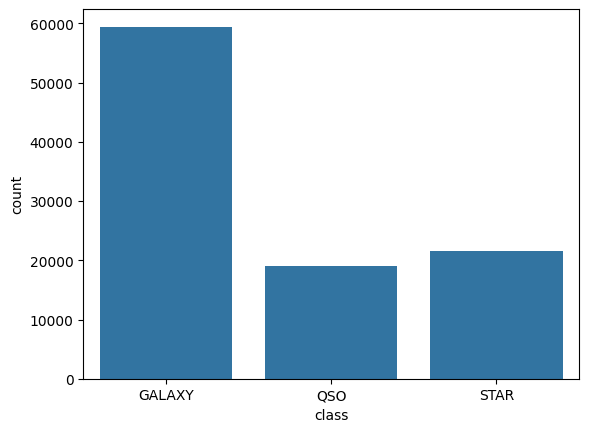

In [10]:
sns.countplot(data=df,x='class')

array([[<Axes: title={'center': 'obj_ID'}>,
        <Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'delta'}>, <Axes: title={'center': 'u'}>],
       [<Axes: title={'center': 'g'}>, <Axes: title={'center': 'r'}>,
        <Axes: title={'center': 'i'}>, <Axes: title={'center': 'z'}>],
       [<Axes: title={'center': 'run_ID'}>,
        <Axes: title={'center': 'rerun_ID'}>,
        <Axes: title={'center': 'cam_col'}>,
        <Axes: title={'center': 'field_ID'}>],
       [<Axes: title={'center': 'spec_obj_ID'}>,
        <Axes: title={'center': 'redshift'}>,
        <Axes: title={'center': 'plate'}>,
        <Axes: title={'center': 'MJD'}>],
       [<Axes: title={'center': 'fiber_ID'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

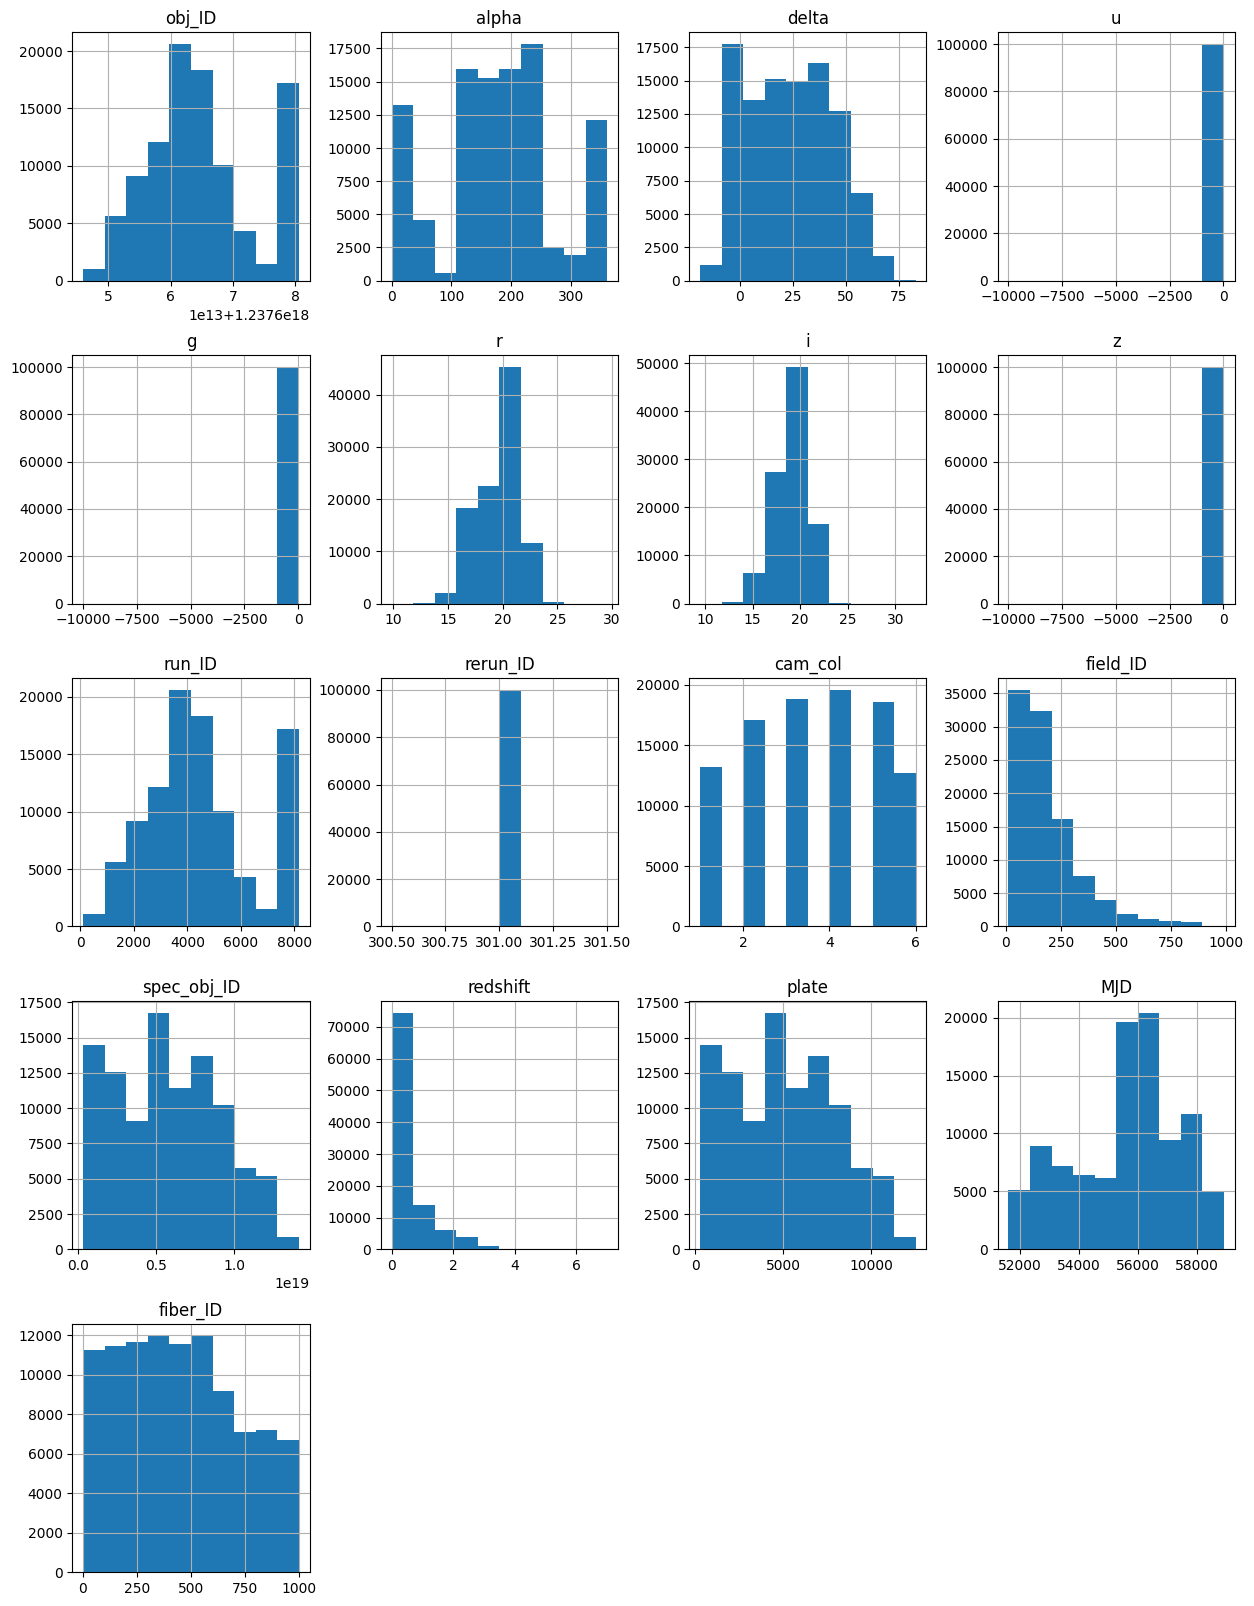

In [11]:
df.hist( figsize = (15 , 20))

<Axes: >

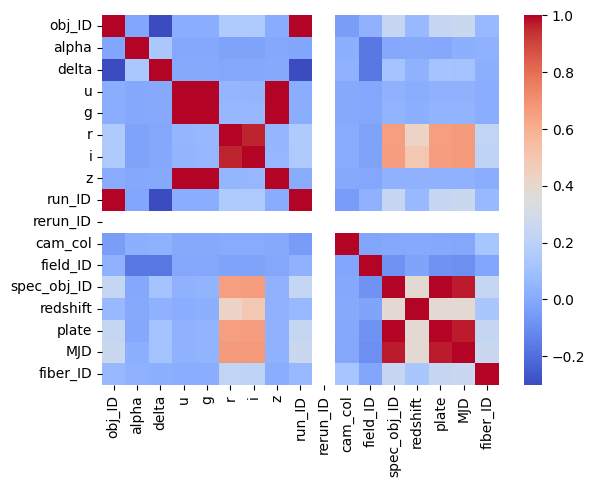

In [12]:
sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm')

<Axes: xlabel='class', ylabel='redshift'>

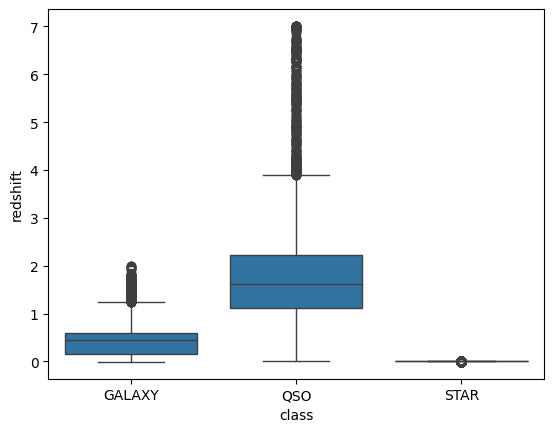

In [13]:
sns.boxplot(
    data=df,
    x='class',
    y='redshift'
)

# WE DROP SOME COLUMNS BECAUSE BASICALLY THEY ARE IDS AND DIDNT CONTRIBUTE TO REAL PROGRESS

In [14]:
drop_cols = [
    'obj_ID',
    'spec_obj_ID',
    'rerun_ID',
    'run_ID',
    'MJD',
    'plate',
    'fiber_ID'
]

df = df.drop(columns=drop_cols)

In [15]:
df.head()

,alpha,delta,u,g,r,i,z,cam_col,field_ID,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,2,79,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,5,119,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,2,120,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,3,214,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,3,137,GALAXY,0.116123


In [16]:
df['class'].value_counts(normalize=True) * 100

class
GALAXY    59.445
STAR      21.594
QSO       18.961
Name: proportion, dtype: float64

In [17]:
le =le()
df['class'] = le.fit_transform(df['class'])

In [18]:
df["class"].sample(10)

10245    0
90384    0
10995    1
27405    2
70853    2
10047    2
66634    2
55734    0
42367    0
44527    0
Name: class, dtype: int32

In [19]:
df["class"].value_counts()

class
0    59445
2    21594
1    18961
Name: count, dtype: int64

In [20]:
x = df.drop("class" , axis = 1)
y = df["class"]

In [21]:
x

,alpha,delta,u,g,r,i,z,cam_col,field_ID,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,2,79,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,5,119,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,2,120,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,3,214,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,3,137,0.116123
...,...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,2,581,0.000000
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,1,289,0.404895
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,4,308,0.143366
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,4,131,0.455040


In [22]:
y

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: class, Length: 100000, dtype: int32

In [23]:
x_train , x_test , y_train , y_test = tts(x , y , test_size = 0.2 , random_state = 42)

In [24]:
x_train.head()

,alpha,delta,u,g,r,i,z,cam_col,field_ID,redshift
75220,155.057478,39.471934,22.32247,21.40113,20.51302,19.62691,19.34791,6,151,0.659869
48955,29.186923,33.102558,25.85486,24.22573,21.48514,20.38426,19.38826,5,116,0.813819
44966,143.780304,16.857367,22.62750,21.41766,19.54710,18.87770,18.39861,2,88,0.404277
13568,154.753807,34.679618,20.25937,18.53387,17.58141,17.16960,16.85448,6,179,0.108840
92727,212.519940,36.429773,22.03892,21.46501,21.32925,21.26120,21.17124,3,521,-0.001039


In [25]:
ss = ss()
x_train_scaled = ss.fit_transform(x_train)
x_test_scaled = ss.transform(x_test)

# USING LOGISTIC REGRESSION

In [26]:
model_logistic = lr(max_iter = 5000)
model_logistic.fit(x_train_scaled , y_train)

LogisticRegression(max_iter=5000)

In [27]:
logistic_pred = model_logistic.predict(x_test_scaled)

In [28]:
accuracy_score(y_test , logistic_pred)

0.9527

In [29]:
print(classification_report(y_test , logistic_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     11860
           1       0.94      0.87      0.91      3797
           2       0.94      1.00      0.97      4343

    accuracy                           0.95     20000
   macro avg       0.95      0.94      0.95     20000
weighted avg       0.95      0.95      0.95     20000



# USING SUPPORT VECTOR MACHINE

In [30]:
svc_model = SVC()
svc_model.fit(x_train_scaled, y_train)

SVC()

In [31]:
svc_pred = svc_model.predict(x_test_scaled)

In [32]:
accuracy_score(y_test,svc_pred)

0.95645

In [33]:
print(classification_report(y_test , svc_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     11860
           1       0.97      0.89      0.93      3797
           2       0.93      1.00      0.96      4343

    accuracy                           0.96     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000



# USING K NEAREST NEIGHBORS

In [34]:
model_knn = knn()
model_knn.fit(x_train_scaled , y_train)

KNeighborsClassifier()

In [35]:
knn_pred = model_knn.predict(x_test_scaled)

In [36]:
accuracy_score(y_test,knn_pred)

0.91605

In [37]:
print(classification_report(y_test , knn_pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93     11860
           1       0.97      0.85      0.91      3797
           2       0.89      0.87      0.88      4343

    accuracy                           0.92     20000
   macro avg       0.92      0.89      0.91     20000
weighted avg       0.92      0.92      0.92     20000



# USING NAIVE BAYES

In [38]:
model_nb = gnb()
model_nb.fit(x_train_scaled, y_train)

GaussianNB()

In [39]:
nb_pred = model_nb.predict(x_test_scaled)

In [40]:
print("Accuracy:", accuracy_score(y_test, nb_pred))

Accuracy: 0.741


In [41]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.76      0.92      0.83     11860
           1       0.66      0.88      0.76      3797
           2       0.98      0.14      0.25      4343

    accuracy                           0.74     20000
   macro avg       0.80      0.65      0.61     20000
weighted avg       0.79      0.74      0.69     20000



# USING DESICION TREE

In [42]:
model_dtc = dtc()
model_dtc.fit(x_train , y_train)

DecisionTreeClassifier()

In [43]:
dtc_pred = model_dtc.predict(x_test)

In [44]:
accuracy_score(y_test , dtc_pred)

0.96535

In [45]:
print(classification_report(y_test , dtc_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     11860
           1       0.92      0.91      0.92      3797
           2       1.00      0.99      0.99      4343

    accuracy                           0.97     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.97      0.97      0.97     20000



# USING RANDOM FOREST CLASSIFIER

In [46]:
model_rfc = rfc(n_estimators=200)
model_rfc.fit(x_train , y_train)

RandomForestClassifier(n_estimators=200)

In [47]:
rfc_pred = model_rfc.predict(x_test)

In [48]:
print(accuracy_score(y_test , rfc_pred))

0.9776


In [49]:
print(classification_report(y_test , rfc_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11860
           1       0.96      0.92      0.94      3797
           2       0.99      1.00      1.00      4343

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



# USING XGBOOST CLASSIFIER

In [50]:
print(y_train.dtype)

int32


In [51]:
model_xgb = xgbc()
model_xgb.fit(x_train , y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [52]:
xgb_pred = model_xgb.predict(x_test)

In [53]:
print(accuracy_score(y_test , xgb_pred))

0.9746


In [54]:
print(classification_report(y_test , xgb_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     11860
           1       0.96      0.93      0.94      3797
           2       0.99      0.99      0.99      4343

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



# LETS COMPARE ALL THE ACCURACY 

In [55]:
print("Logistic Regression = " , accuracy_score(y_test , logistic_pred))
print("SVM =" , accuracy_score(y_test , svc_pred))
print("KNN =" , accuracy_score(y_test , knn_pred))
print("NB =" , accuracy_score(y_test, nb_pred))
print("Desicion Tree =" , accuracy_score(y_test , dtc_pred))
print("Random Forest =" , accuracy_score(y_test , rfc_pred))
print("XGBoost =" , accuracy_score(y_test , xgb_pred))

Logistic Regression =  0.9527
SVM = 0.95645
KNN = 0.91605
NB = 0.741
Desicion Tree = 0.96535
Random Forest = 0.9776
XGBoost = 0.9746


# SO , WE ARE GOING TO GO WITH RANDOM FOREST CLASSIFIER

In [56]:
scores = cross_val_score(
    model_rfc,
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.9783  0.97865 0.9777  0.9794  0.97725]
Mean CV Accuracy: 0.97826


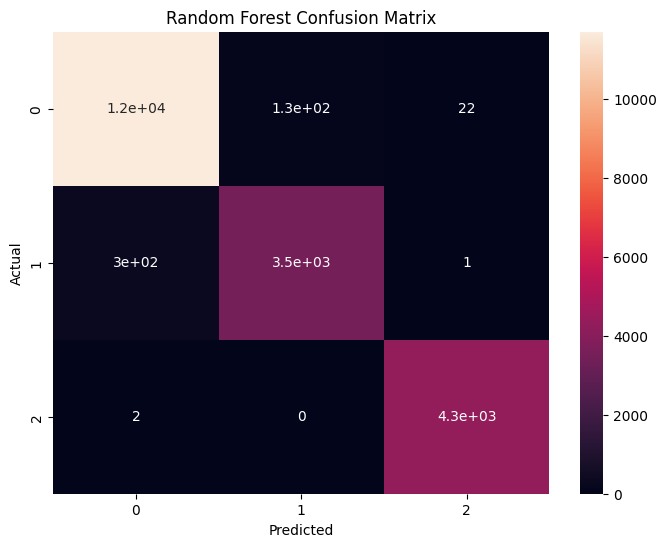

In [57]:
cm = confusion_matrix(y_test , rfc_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,

)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [58]:
model_rfc.feature_importances_

array([0.01124132, 0.01130955, 0.05501228, 0.06992582, 0.03899355,
       0.05958951, 0.0970153 , 0.0028295 , 0.00706949, 0.64701367])

In [73]:
importance = model_rfc.feature_importances_
importance

array([0.01124132, 0.01130955, 0.05501228, 0.06992582, 0.03899355,
       0.05958951, 0.0970153 , 0.0028295 , 0.00706949, 0.64701367])

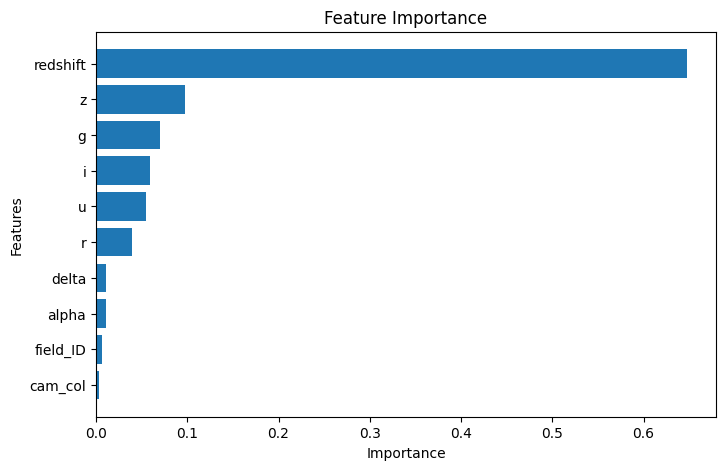

In [59]:


# Get feature importance
importance = model_rfc.feature_importances_

# Create dataframe
feature_imp = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
})

# Sort values
feature_imp = feature_imp.sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feature_imp['Feature'],
         feature_imp['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# LETS MOVE TO DEPLOYMENT

In [60]:
import os

os.listdir()

['.ipynb_checkpoints',
 'Description.docx',
 'star_classification.csv',
 'Stellar Object Classification Using Machine Learning.pdf',
 'stellar-classification-app',
 'testing.ipynb']

In [61]:
x.head()

,alpha,delta,u,g,r,i,z,cam_col,field_ID,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,2,79,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,5,119,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,2,120,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,3,214,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,3,137,0.116123


In [62]:
x.columns.tolist()

['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'cam_col', 'field_ID', 'redshift']

In [63]:
df.head()

,alpha,delta,u,g,r,i,z,cam_col,field_ID,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,2,79,0,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,5,119,0,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,2,120,0,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,3,214,0,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,3,137,0,0.116123
